<a href="https://colab.research.google.com/github/edtallison/interp-notebooks/blob/main/linear_probe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torch transformers

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

print(torch.__version__)

model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

model.eval()

2.11.0+cpu


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
countries_capitals = [
    ("France", "Paris"), ("Japan", "Tokyo"), ("Italy", "Rome"),
    ("Germany", "Berlin"), ("Spain", "Madrid"), ("Egypt", "Cairo"),
    ("Canada", "Ottawa"), ("Brazil", "Brasilia"), ("Russia", "Moscow"),
    ("China", "Beijing"), ("India", "New Delhi"), ("Australia", "Canberra"),
    ("Mexico", "Mexico City"), ("Argentina", "Buenos Aires"), ("Chile", "Santiago"),
    ("Peru", "Lima"), ("Colombia", "Bogota"), ("Portugal", "Lisbon"),
    ("Greece", "Athens"), ("Turkey", "Ankara"), ("Poland", "Warsaw"),
    ("Sweden", "Stockholm"), ("Norway", "Oslo"), ("Finland", "Helsinki"),
    ("Denmark", "Copenhagen"), ("Netherlands", "Amsterdam"), ("Belgium", "Brussels"),
    ("Austria", "Vienna"), ("Switzerland", "Bern"), ("Ireland", "Dublin"),
    ("Thailand", "Bangkok"), ("Vietnam", "Hanoi"), ("Indonesia", "Jakarta"),
    ("Philippines", "Manila"), ("Malaysia", "Kuala Lumpur"), ("South Korea", "Seoul"),
    ("Nigeria", "Abuja"), ("Kenya", "Nairobi"), ("Morocco", "Rabat"),
    ("South Africa", "Pretoria"), ("Ghana", "Accra"), ("Ethiopia", "Addis Ababa"),
    ("Saudi Arabia", "Riyadh"), ("Iran", "Tehran"), ("Iraq", "Baghdad"),
    ("Israel", "Jerusalem"), ("Pakistan", "Islamabad"), ("Bangladesh", "Dhaka"),
    ("Ukraine", "Kyiv"), ("Hungary", "Budapest"), ("Czechia", "Prague"),
]

# Shuffle capitals against countries (offset by a fixed amount, wrapping around)
# so each wrong pairing is a real capital, just mismatched to the wrong country.
import random
random.seed(42)

capitals_only = [cap for _, cap in countries_capitals]
shuffled_capitals = capitals_only.copy()
random.shuffle(shuffled_capitals)

# Ensure no country accidentally gets its own correct capital as the "wrong" one
for i, (country, correct_cap) in enumerate(countries_capitals):
    if shuffled_capitals[i] == correct_cap:
        # swap with the next index to break the collision
        j = (i + 1) % len(shuffled_capitals)
        shuffled_capitals[i], shuffled_capitals[j] = shuffled_capitals[j], shuffled_capitals[i]

data = []
for (country, correct), wrong in zip(countries_capitals, shuffled_capitals):
    data.append((f"The capital of {country} is {correct}", 1))
    data.append((f"The capital of {country} is {wrong}", 0))

random.shuffle(data)  # avoid all-correct-then-all-wrong ordering

print(f"Total examples: {len(data)}")
print(data[:6])

Total examples: 102
[('The capital of Norway is Oslo', 1), ('The capital of Peru is Lima', 1), ('The capital of Poland is Warsaw', 1), ('The capital of Egypt is Madrid', 0), ('The capital of China is Beijing', 1), ('The capital of South Korea is Prague', 0)]


In [ ]:
def get_all_layer_activations(prompt):
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    # returns list of (hidden_dim,) vectors, one per layer
    return [h[0, -1, :] for h in outputs.hidden_states]

all_activations = [get_all_layer_activations(p) for p, _ in data]
labels = [label for _, label in data]
n_layers = len(all_activations[0])

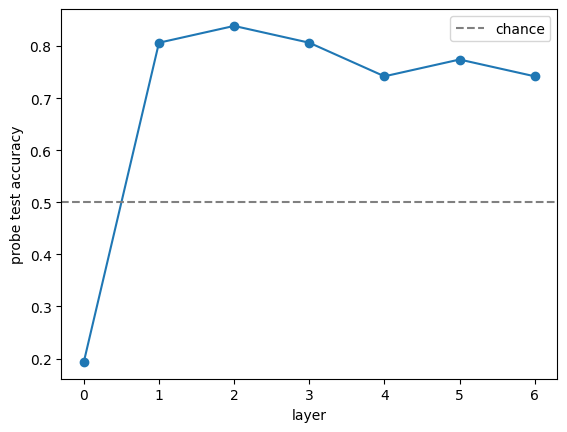

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import numpy as np

accs = []
for layer in range(n_layers):
    X = np.stack([acts[layer].numpy() for acts in all_activations])
    y = np.array(labels)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=0, stratify=y
    )
    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train, y_train)
    accs.append(probe.score(X_test, y_test))

import matplotlib.pyplot as plt
plt.plot(range(n_layers), accs, marker='o')
plt.xlabel("layer")
plt.ylabel("probe test accuracy")
plt.axhline(0.5, color='gray', linestyle='--', label='chance')
plt.legend()
plt.show()